# `DirectorPair` — emergent nematic vs polar order

`hoomd.align_angle.DirectorPair` is an **orientation-dependent pair potential**:
neighbouring particles attract most when their body-axes
$\hat n = \mathrm{rotate}(q, \hat x)$ are aligned, with the symmetry set by the
`multiplicity` $m$:

$$U_{ij} = -\epsilon\,\cos\!\bigl(m\,\alpha_{ij} + \varphi_0\bigr)
          \left(1 - r_{ij}^2/r_c^2\right)^2,\qquad
\alpha_{ij} = \arccos(\hat n_i \cdot \hat n_j).$$

| `multiplicity` | favoured arrangement | symmetry |
|----------------|----------------------|----------|
| `1` (polar) | parallel only ($\hat n_i \!\parallel\! \hat n_j$) | vector / ferroelectric |
| `2` (nematic) | parallel **and** anti-parallel | head–tail symmetric |

**What this demo shows.** From a disordered gas of randomly-oriented particles,
`DirectorPair` drives **spontaneous orientational ordering**. The same force with
`multiplicity=2` gives a **nematic** (particles share an *axis*; a neighbour is as
happy pointing with you as against you) while `multiplicity=1` gives a **polar**
state (neighbours point the *same way*). We run both from an identical start and
read the order parameter and the pairwise-alignment distribution straight from the
trajectories.

One linear pipeline per case — **configure → forces → Langevin** — with all
plotting deferred to the final section.

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

import hoomd
import hoomd.md
import gsd.hoomd

from hoomd import align_angle

import demo_viz as v   # viz/analysis only; used below the divider

try:
    device = hoomd.device.GPU()
except Exception:
    device = hoomd.device.CPU()
print("HOOMD", hoomd.version.version, "| device:", type(device).__name__,
      "| precision", hoomd.version.floating_point_precision)

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Parameters

In [2]:
N        = 4000       # particles (small enough to anneal into a single monodomain;
                      # much larger systems freeze into competing domains — see the end)
DENSITY  = 3.0        # number density (DPD units)
DPD_A    = 25.0       # DPD conservative repulsion amplitude
EPS      = 2.0        # DirectorPair strength (same for both cases)
RC_PAIR  = 1.5        # DirectorPair cutoff
kT       = 1.0

DT_WARM, WARMUP = 0.002, 2000        # brief soft warmup
DT, NUM_BLOCKS, BLOCK = 0.01, 50, 1000

L = (N / DENSITY) ** (1 / 3)         # cubic periodic box
CASES = {"nematic": 2, "polar": 1}   # label -> multiplicity

OUT_DIR = pathlib.Path("./director_pair_traj")
OUT_DIR.mkdir(exist_ok=True)
INIT_GSD = OUT_DIR / "init.gsd"
traj_path = lambda label: OUT_DIR / f"{label}.gsd"
print(f"N = {N}, box L = {L:.2f}, density = {N / L**3:.2f}")

N = 4000, box L = 11.01, density = 3.00


## 2. Initial state

A gas of `N` particles at random positions with **random orientations** (uniform
unit quaternions) in a periodic box — orientationally disordered, so any order we
see later is emergent. Each particle gets a moment of inertia so its orientation
is a dynamical (rotational) degree of freedom.

In [3]:
rng = np.random.default_rng(42)
frame = gsd.hoomd.Frame()
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.N = N
frame.particles.types = ["A"]
frame.particles.typeid = np.zeros(N, dtype=int)
frame.particles.position = (rng.random((N, 3)) - 0.5) * L
q = rng.normal(size=(N, 4)); q /= np.linalg.norm(q, axis=1, keepdims=True)
frame.particles.orientation = q
frame.particles.moment_inertia = np.tile([1.0, 1.0, 1.0], (N, 1))
frame.particles.mass = np.ones(N)
with gsd.hoomd.open(name=str(INIT_GSD), mode="w") as f:
    f.append(frame)
print(f"wrote {INIT_GSD}")

wrote director_pair_traj/init.gsd


## 3. Run both cases

`run_case` builds a self-contained simulation: a soft **DPD** repulsion for
excluded volume plus **`DirectorPair`** for the orientational coupling, integrated
with a Langevin thermostat on both translational and rotational DOF. Each case
streams its own trajectory; we analyse them afterwards. (Both start from the same
`init.gsd`.)

In [4]:
def run_case(label, multiplicity):
    sim = hoomd.Simulation(device=device, seed=12345)
    sim.create_state_from_gsd(filename=str(INIT_GSD))
    sim.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=kT)

    cell = hoomd.md.nlist.Cell(buffer=0.4)                       # dense box -> Cell
    dpd = hoomd.md.pair.DPDConservative(nlist=cell, default_r_cut=1.0)
    dpd.params[("A", "A")] = dict(A=DPD_A)
    pair = align_angle.DirectorPair(nlist=cell, default_r_cut=RC_PAIR)
    pair.params[("A", "A")] = dict(epsilon=EPS, multiplicity=multiplicity)

    lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=kT)
    lang.gamma_r["A"] = (1.0, 1.0, 1.0)                          # rotational bath
    integ = hoomd.md.Integrator(dt=DT_WARM, methods=[lang], forces=[dpd, pair],
                                integrate_rotational_dof=True)
    sim.operations.integrator = integ

    writer = hoomd.write.GSD(filename=str(traj_path(label)), mode="wb",
                             trigger=hoomd.trigger.Periodic(BLOCK), dynamic=["property"])
    sim.operations.writers.append(writer)

    sim.run(WARMUP)                     # soft warmup at small dt
    integ.dt = DT
    for _ in range(NUM_BLOCKS):
        sim.run(BLOCK)
    writer.flush()
    assert isinstance(pair, align_angle.DirectorPair) and abs(pair.energy) > 0
    print(f"[{label:>7s}] m={multiplicity}  done, {sim.timestep} steps, "
          f"U_pair/N = {pair.energy / N:.3f}")


for label, mult in CASES.items():
    run_case(label, mult)
print("[PASS] both cases ran; DirectorPair exercised")

[nematic] m=2  done, 52000 steps, U_pair/N = -310.390


[  polar] m=1  done, 52000 steps, U_pair/N = -150.011
[PASS] both cases ran; DirectorPair exercised


# ═══════ EXECUTION COMPLETE — VISUALIZATION & ANALYSIS BELOW ═══════

## 4. The nematic monodomain: before vs after

A thin slab of the box (so the arrows aren't occluded), showing each particle's
director. The initial gas is isotropic; under `DirectorPair` (`m=2`) it settles
onto a single common **axis** — arrows point both ways along it, coloured by
$|\hat n \cdot \hat N|$ (alignment with the mean axis $\hat N$). The polar case is
compared quantitatively in the next section (its vector order frustrates into
domains, so a single global snapshot is less telling).

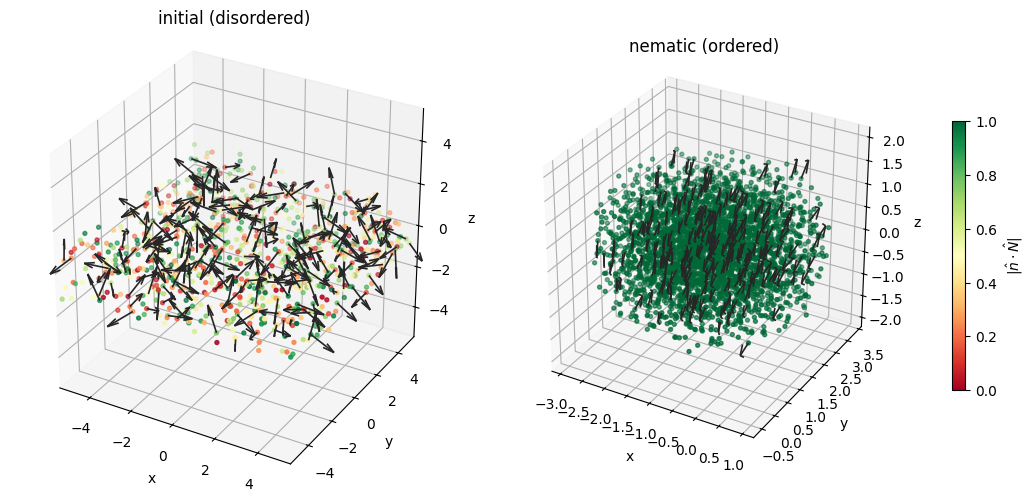

In [5]:
def frame_state(fr):
    return np.asarray(fr.particles.position), v.director_from_quat(np.asarray(fr.particles.orientation))


def slab(pos, dirs, half=1.2):
    m = np.abs(pos[:, 2]) < half        # thin z-slab
    return pos[m], dirs[m]


panels = [("initial (disordered)", gsd.hoomd.open(name=str(INIT_GSD))[0]),
          ("nematic (ordered)", gsd.hoomd.open(name=str(traj_path("nematic")))[-1])]

fig = plt.figure(figsize=(11, 5))
for k, (title, fr) in enumerate(panels):
    pos, dirs = frame_state(fr)
    _, N_axis = v.nematic_order(dirs)                # mean orientation axis
    ps, ds = slab(pos, dirs)
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    v.render3d(ps, directors=ds, color=np.abs(ds @ N_axis), every=max(1, len(ps) // 200),
               cmap="RdYlGn", clim=(0, 1), colorbar=(k == 1), clabel=r"$|\hat n\cdot\hat N|$",
               arrow_len=1.2, arrow_color="0.15", title=title, ax=ax)
fig.tight_layout(); plt.show()

## 5. Order parameter and pairwise alignment

**Left:** the nematic order parameter $S$ (largest eigenvalue of the Q-tensor)
rising from ~0 (isotropic) as each case orders — nematic saturates near 1, polar
plateaus lower (vector order is more frustrated). **Right:** the signed neighbour
alignment $\hat n_i\!\cdot\!\hat n_j$ — the telltale difference: **nematic peaks at
both $\pm1$** (parallel *and* anti-parallel neighbours) while **polar peaks only at
$+1$**.

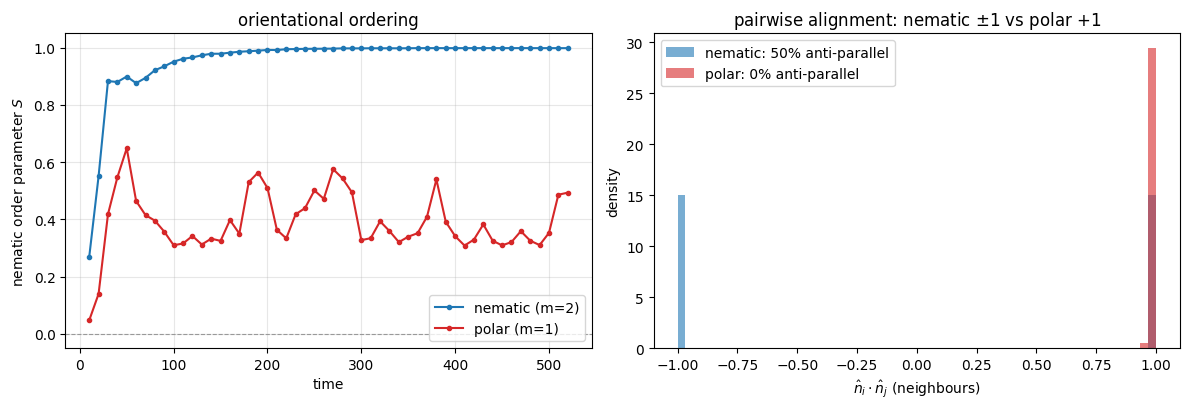

final S: {'nematic': np.float64(0.998), 'polar': np.float64(0.493)}


In [6]:
def S_series(label):
    traj = gsd.hoomd.open(name=str(traj_path(label)))
    t = np.array([fr.configuration.step for fr in traj]) * DT
    S = np.array([v.nematic_order(v.director_from_quat(np.asarray(fr.particles.orientation)))[0]
                  for fr in traj])
    return t, S


def signed_pair_dots(fr):
    pos, dirs = frame_state(fr)
    wrapped = (pos + L / 2) % L                       # cKDTree needs [0, L)
    pairs = cKDTree(wrapped, boxsize=L).query_pairs(r=RC_PAIR, output_type="ndarray")
    return np.sum(dirs[pairs[:, 0]] * dirs[pairs[:, 1]], axis=1)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
colors = {"nematic": "C0", "polar": "C3"}
for lab in CASES:
    t, S = S_series(lab)
    ax1.plot(t, S, "-o", ms=3, color=colors[lab], label=f"{lab} (m={CASES[lab]})")
ax1.axhline(0, ls="--", color="0.6", lw=0.8)
ax1.set_xlabel("time"); ax1.set_ylabel("nematic order parameter $S$")
ax1.set_ylim(-0.05, 1.05); ax1.set_title("orientational ordering"); ax1.legend()
ax1.grid(alpha=0.3)

bins = np.linspace(-1, 1, 61)
for lab in CASES:
    c = signed_pair_dots(gsd.hoomd.open(name=str(traj_path(lab)))[-1])
    ax2.hist(c, bins=bins, density=True, alpha=0.6, color=colors[lab],
             label=f"{lab}: {(c < 0).mean():.0%} anti-parallel")
ax2.set_xlabel(r"$\hat n_i \cdot \hat n_j$ (neighbours)"); ax2.set_ylabel("density")
ax2.set_title("pairwise alignment: nematic $\\pm1$ vs polar $+1$"); ax2.legend()
fig.tight_layout(); plt.show()

Sfin = {lab: S_series(lab)[1][-1] for lab in CASES}
print("final S:", {k: round(x, 3) for k, x in Sfin.items()})
assert Sfin["nematic"] > 0.8, "nematic should order strongly"


## What to try next

- **Temperature sweep:** raise `kT` toward the isotropic–nematic transition — `S`
  drops sharply once thermal noise beats the $\epsilon$ coupling.
- **Anti-alignment:** `phase=np.pi` with `multiplicity=1` favours *anti*-parallel
  neighbours (the pairwise peak moves to $-1$).
- **Bigger systems form domains:** push `N` to 10⁴–10⁵ and the fast quench freezes
  into competing nematic **domains** (low global `S`, though local order is high) —
  reaching a single monodomain then needs slow annealing (ramp `epsilon` up, or cool
  gradually).
- **Density:** lower `DENSITY` toward a dilute gas — ordering weakens as neighbours
  become rare.